In [1]:
# ============================================
# CUSTOMER CHURN PREDICTION
# Step 1: Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# STEP 2: LOAD CUSTOMER CHURN DATASET
# ============================================

import pandas as pd

# Working dataset URL
url = "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd4.5/data/customer_churn/WA_FnUseC_TelcoCustomerChurn.csv"

# Load dataset
df = pd.read_csv(url)

# Display basic information
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display first 5 rows
df.head()

Dataset loaded successfully!
Number of rows: 7043
Number of columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ============================================
# STEP 3: DATASET INSPECTION
# ============================================

# 1. Dataset information
print("========== DATASET INFORMATION ==========")
df.info()

# 2. Check missing values
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# 3. Check duplicate rows
print("\n========== DUPLICATE ROWS ==========")
print("Number of duplicate rows:", df.duplicated().sum())

# 4. Check target variable
print("\n========== CHURN DISTRIBUTION ==========")
print(df["Churn"].value_counts())

# 5. Churn percentage
print("\n========== CHURN PERCENTAGE ==========")
print(df["Churn"].value_counts(normalize=True) * 100)

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  

In [4]:
# ============================================
# STEP 4: DATA CLEANING
# ============================================

# Make a copy of the original dataset
data = df.copy()

# --------------------------------------------
# 1. Remove customerID
# --------------------------------------------

data.drop("customerID", axis=1, inplace=True)

# --------------------------------------------
# 2. Convert TotalCharges to numeric
# --------------------------------------------

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# --------------------------------------------
# 3. Check missing values created during
#    numeric conversion
# --------------------------------------------

print("Missing values after converting TotalCharges:")
print(data.isnull().sum())

# --------------------------------------------
# 4. Remove rows with missing TotalCharges
# --------------------------------------------

data.dropna(inplace=True)

# --------------------------------------------
# 5. Convert Churn into numerical values
#    No  = 0
#    Yes = 1
# --------------------------------------------

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

# --------------------------------------------
# 6. Display cleaned dataset information
# --------------------------------------------

print("\n========== CLEANED DATASET ==========")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

print("\nData types:")
print(data.dtypes)

print("\nFirst 5 rows:")
display(data.head())

Missing values after converting TotalCharges:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

========== CLEANED DATASET ==========
Rows: 7032
Columns: 20

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract      

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


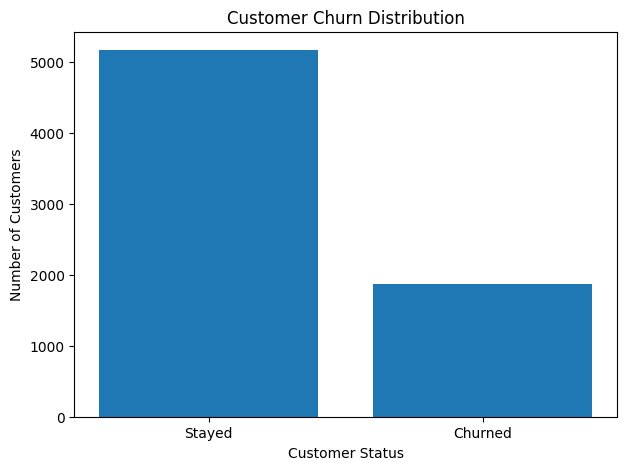

Stayed: 5163
Churned: 1869

Churn Rate: 26.58%


In [5]:
# ============================================
# STEP 5.1: CHURN DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

churn_counts = data["Churn"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Stayed", "Churned"],
    [churn_counts[0], churn_counts[1]]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

print("Stayed:", churn_counts[0])
print("Churned:", churn_counts[1])

print("\nChurn Rate: {:.2f}%".format(
    data["Churn"].mean() * 100
))

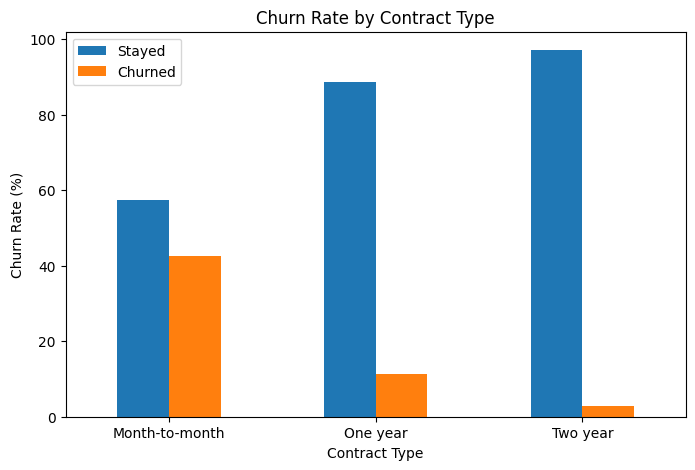

Churn percentage by contract type:


Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [6]:
# ============================================
# STEP 5.2: CHURN BY CONTRACT TYPE
# ============================================

contract_churn = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])

plt.show()

print("Churn percentage by contract type:")
display(contract_churn)

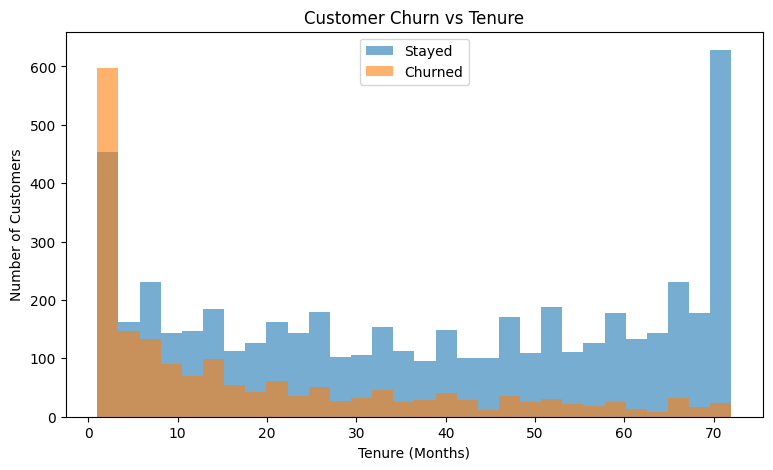

In [7]:
# ============================================
# STEP 5.3: CHURN VS TENURE
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    data[data["Churn"] == 0]["tenure"],
    bins=30,
    alpha=0.6,
    label="Stayed"
)

plt.hist(
    data[data["Churn"] == 1]["tenure"],
    bins=30,
    alpha=0.6,
    label="Churned"
)

plt.title("Customer Churn vs Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

<Figure size 800x500 with 0 Axes>

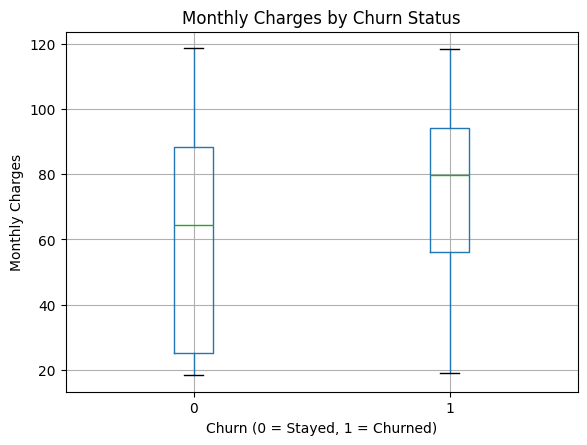

In [8]:
# ============================================
# STEP 5.4: MONTHLY CHARGES VS CHURN
# ============================================

plt.figure(figsize=(8, 5))

data.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Charges")

plt.show()

In [9]:
# ============================================
# STEP 6: FEATURE & TARGET PREPARATION
# ============================================

# Separate features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Identify numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("========== FEATURE INFORMATION ==========")

print("\nNumerical Features:")
for feature in numerical_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)

print("\nTotal features:", X.shape[1])
print("Total samples:", X.shape[0])

========== FEATURE INFORMATION ==========

Numerical Features:
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges

Categorical Features:
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod

Total features: 19
Total samples: 7032


In [10]:
# ============================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("========== TRAIN-TEST SPLIT ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True) * 100)

========== TRAIN-TEST SPLIT ==========
Training samples: 5625
Testing samples: 1407

Training churn distribution:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [11]:
# ============================================
# STEP 8: DATA PREPROCESSING PIPELINE
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [12]:
# ============================================
# STEP 9: LOGISTIC REGRESSION MODEL
# ============================================

from sklearn.linear_model import LogisticRegression

# Create complete pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
# ============================================
# STEP 10: EVALUATE LOGISTIC REGRESSION
# ============================================

# Make predictions
y_pred = logistic_model.predict(X_test)

# Get probability of churn
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("========== LOGISTIC REGRESSION RESULTS ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy  : 0.8038
Precision : 0.6485
Recall    : 0.5722
F1-Score  : 0.6080
ROC-AUC   : 0.8359

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



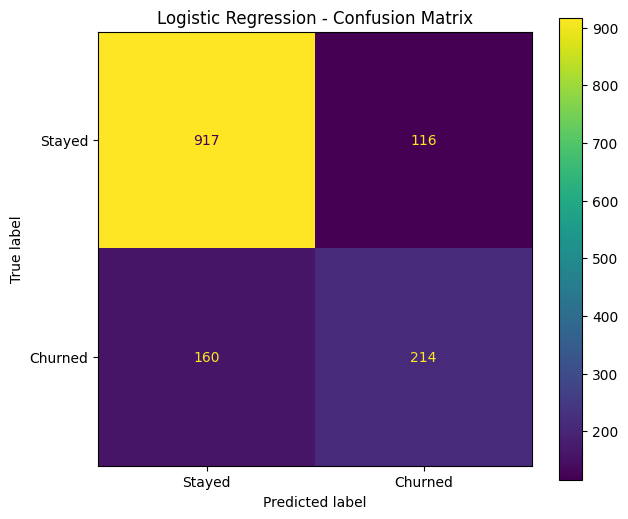

Confusion Matrix:
[[917 116]
 [160 214]]


In [14]:
# ============================================
# STEP 11: CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(cm)

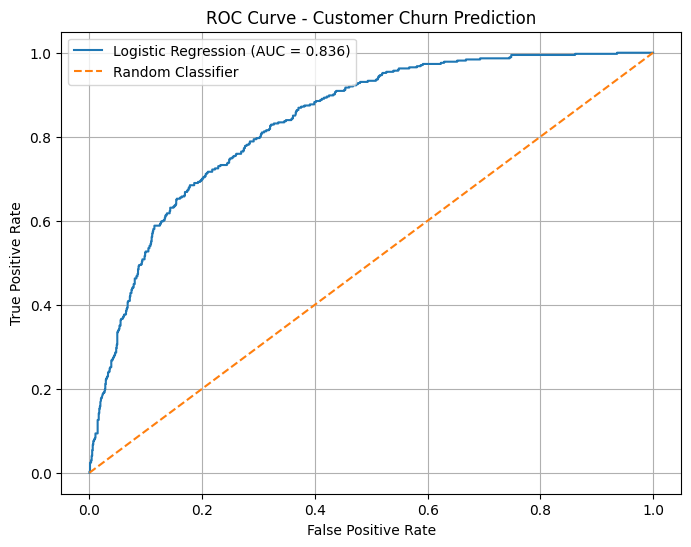

In [15]:
# ============================================
# STEP 12: ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid()

plt.show()

In [16]:
# ============================================
# STEP 13: RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [17]:
# ============================================
# STEP 14: RANDOM FOREST EVALUATION
# ============================================

# Predictions
rf_pred = random_forest_model.predict(X_test)

# Churn probabilities
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("========== RANDOM FOREST RESULTS ==========")

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Stayed", "Churned"]
    )
)

========== RANDOM FOREST RESULTS ==========
Accuracy  : 0.7569
Precision : 0.5310
Recall    : 0.7326
F1-Score  : 0.6157
ROC-AUC   : 0.8314

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Stayed       0.89      0.77      0.82      1033
     Churned       0.53      0.73      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



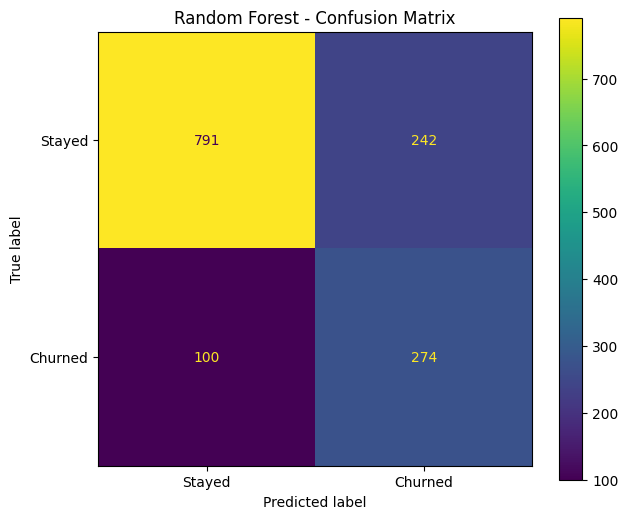

Confusion Matrix:
[[791 242]
 [100 274]]


In [18]:
# ============================================
# STEP 15: RANDOM FOREST CONFUSION MATRIX
# ============================================

rf_cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Stayed", "Churned"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(rf_cm)

In [19]:
# ============================================
# STEP 16: MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

print("========== MODEL COMPARISON ==========")

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Random Forest,0.7569,0.5310,0.7326,0.6157,0.8314


In [20]:
# ============================================
# STEP 17: GRADIENT BOOSTING MODEL
# ============================================

from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

# Train the model
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [21]:
# ============================================
# STEP 18: GRADIENT BOOSTING EVALUATION
# ============================================

# Predictions
gb_pred = gradient_boosting_model.predict(X_test)

# Churn probabilities
gb_prob = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Calculate metrics
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_prob)

print("========== GRADIENT BOOSTING RESULTS ==========")

print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1-Score  : {gb_f1:.4f}")
print(f"ROC-AUC   : {gb_roc_auc:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        gb_pred,
        target_names=["Stayed", "Churned"]
    )
)

========== GRADIENT BOOSTING RESULTS ==========
Accuracy  : 0.7932
Precision : 0.6326
Recall    : 0.5294
F1-Score  : 0.5764
ROC-AUC   : 0.8392

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1033
     Churned       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [22]:
# ============================================
# STEP 19: FINAL MODEL COMPARISON
# ============================================

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        gb_recall
    ],
    "F1-Score": [
        f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

print("========== FINAL MODEL COMPARISON ==========")

display(
    final_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

========== FINAL MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
1,Random Forest,0.7569,0.5310,0.7326,0.6157,0.8314
2,Gradient Boosting,0.7932,0.6326,0.5294,0.5764,0.8392


In [23]:
# ============================================
# STEP 20: LOGISTIC REGRESSION FEATURE IMPORTANCE
# ============================================

# Get the preprocessing part of the trained pipeline
preprocessor_fitted = logistic_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps["classifier"].coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("========== TOP 20 IMPORTANT FEATURES ==========")

display(
    feature_importance.head(20)
)

========== TOP 20 IMPORTANT FEATURES ==========


,Feature,Coefficient,Absolute_Importance
1,num__tenure,-1.352313,1.352313
38,cat__Contract_Two year,-0.779030,0.779030
3,num__TotalCharges,0.644014,0.644014
15,cat__InternetService_DSL,-0.616132,0.616132
36,cat__Contract_Month-to-month,0.613846,0.613846
16,cat__InternetService_Fiber optic,0.590184,0.590184
2,num__MonthlyCharges,-0.541006,0.541006
39,cat__PaperlessBilling_No,-0.300387,0.300387
12,cat__MultipleLines_No,-0.293470,0.293470
17,cat__InternetService_No,-0.283724,0.283724


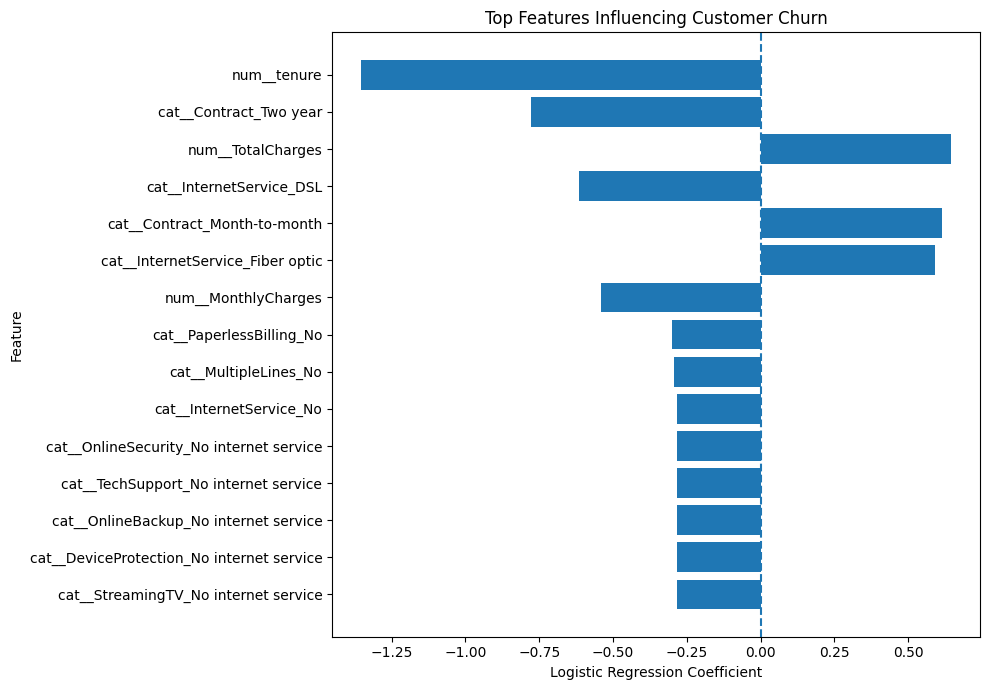

In [24]:
# ============================================
# STEP 21: FEATURE IMPORTANCE VISUALIZATION
# ============================================

top_features = feature_importance.head(15).sort_values(
    "Absolute_Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Customer Churn")

plt.axvline(
    x=0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# STEP 22: CUSTOMER CHURN PREDICTION FUNCTION
# ============================================

def predict_customer_churn(customer_data):
    """
    Predict whether a customer is likely to churn.

    Parameters:
        customer_data: pandas DataFrame containing
                       customer information.

    Returns:
        Prediction and churn probability.
    """

    prediction = logistic_model.predict(customer_data)[0]

    probability = logistic_model.predict_proba(
        customer_data
    )[0][1]

    result = "LIKELY TO CHURN" if prediction == 1 else "LIKELY TO STAY"

    print("========================================")
    print("       CUSTOMER CHURN PREDICTION")
    print("========================================")
    print(f"Prediction       : {result}")
    print(f"Churn Probability: {probability * 100:.2f}%")
    print("========================================")

    return prediction, probability

In [26]:
# ============================================
# STEP 23: TEST CUSTOMER
# ============================================

sample_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [2],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.0],
    "TotalCharges": [170.0]
})

predict_customer_churn(sample_customer)

       CUSTOMER CHURN PREDICTION
Prediction       : LIKELY TO CHURN
Churn Probability: 79.20%


(np.int64(1), np.float64(0.7919850523740843))

In [27]:
# ============================================
# STEP 24: SAVE TRAINED MODEL
# ============================================

import joblib

# Save the complete Logistic Regression pipeline
joblib.dump(
    logistic_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")
print("File: customer_churn_model.pkl")

Model saved successfully!
File: customer_churn_model.pkl


In [28]:
# ============================================
# STEP 25: LOAD AND VERIFY SAVED MODEL
# ============================================

import joblib

# Load the saved model
loaded_model = joblib.load("customer_churn_model.pkl")

print("Saved model loaded successfully!")

# Make prediction using the loaded model
loaded_prediction = loaded_model.predict(sample_customer)[0]

loaded_probability = loaded_model.predict_proba(
    sample_customer
)[0][1]

print("\n========== SAVED MODEL TEST ==========")

if loaded_prediction == 1:
    print("Prediction       : LIKELY TO CHURN")
else:
    print("Prediction       : LIKELY TO STAY")

print(f"Churn Probability: {loaded_probability * 100:.2f}%")

Saved model loaded successfully!

========== SAVED MODEL TEST ==========
Prediction       : LIKELY TO CHURN
Churn Probability: 79.20%


In [29]:
# ============================================
# STEP 26.1: INSTALL GRADIO
# ============================================

!pip install -q gradio

print("Gradio installed successfully!")

Gradio installed successfully!


In [30]:
# ============================================
# STEP 26.2: FIXED GRADIO PREDICTION FUNCTION
# ============================================

def gradio_predict(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):

    try:
        # Convert numeric inputs
        tenure = float(tenure)
        monthly_charges = float(monthly_charges)
        total_charges = float(total_charges)

        # Convert Senior Citizen
        senior_citizen_value = 1 if senior_citizen == "Yes" else 0

        # Create dataframe with EXACT same columns
        customer = pd.DataFrame({
            "gender": [gender],
            "SeniorCitizen": [senior_citizen_value],
            "Partner": [partner],
            "Dependents": [dependents],
            "tenure": [tenure],
            "PhoneService": [phone_service],
            "MultipleLines": [multiple_lines],
            "InternetService": [internet_service],
            "OnlineSecurity": [online_security],
            "OnlineBackup": [online_backup],
            "DeviceProtection": [device_protection],
            "TechSupport": [tech_support],
            "StreamingTV": [streaming_tv],
            "StreamingMovies": [streaming_movies],
            "Contract": [contract],
            "PaperlessBilling": [paperless_billing],
            "PaymentMethod": [payment_method],
            "MonthlyCharges": [monthly_charges],
            "TotalCharges": [total_charges]
        })

        # Make prediction using saved model
        prediction = loaded_model.predict(customer)[0]

        # Get probability
        probability = loaded_model.predict_proba(customer)[0][1]

        # Result
        if prediction == 1:
            result = "⚠️ LIKELY TO CHURN"
        else:
            result = "✅ LIKELY TO STAY"

        return (
            result,
            f"{probability * 100:.2f}%"
        )

    except Exception as e:

        # Show actual error instead of generic Gradio error
        print("ERROR:", str(e))

        return (
            "❌ Prediction Error",
            str(e)
        )

In [31]:
# ============================================
# STEP 26.3: CREATE FIXED GRADIO INTERFACE
# ============================================

import gradio as gr

demo = gr.Interface(
    fn=gradio_predict,

    inputs=[
        gr.Dropdown(
            ["Female", "Male"],
            value="Female",
            label="Gender"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            value="No",
            label="Senior Citizen"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            value="No",
            label="Partner"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            value="No",
            label="Dependents"
        ),

        gr.Number(
            value=2,
            label="Tenure (Months)"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            value="Yes",
            label="Phone Service"
        ),

        gr.Dropdown(
            ["No", "Yes", "No phone service"],
            value="No",
            label="Multiple Lines"
        ),

        gr.Dropdown(
            ["DSL", "Fiber optic", "No"],
            value="Fiber optic",
            label="Internet Service"
        ),

        gr.Dropdown(
            ["No", "Yes", "No internet service"],
            value="No",
            label="Online Security"
        ),

        gr.Dropdown(
            ["No", "Yes", "No internet service"],
            value="No",
            label="Online Backup"
        ),

        gr.Dropdown(
            ["No", "Yes", "No internet service"],
            value="No",
            label="Device Protection"
        ),

        gr.Dropdown(
            ["No", "Yes", "No internet service"],
            value="No",
            label="Tech Support"
        ),

        gr.Dropdown(
            ["No", "Yes", "No internet service"],
            value="Yes",
            label="Streaming TV"
        ),

        gr.Dropdown(
            ["No", "Yes", "No internet service"],
            value="Yes",
            label="Streaming Movies"
        ),

        gr.Dropdown(
            ["Month-to-month", "One year", "Two year"],
            value="Month-to-month",
            label="Contract"
        ),

        gr.Dropdown(
            ["No", "Yes"],
            value="Yes",
            label="Paperless Billing"
        ),

        gr.Dropdown(
            [
                "Electronic check",
                "Mailed check",
                "Bank transfer (automatic)",
                "Credit card (automatic)"
            ],
            value="Electronic check",
            label="Payment Method"
        ),

        gr.Number(
            value=85.0,
            label="Monthly Charges"
        ),

        gr.Number(
            value=170.0,
            label="Total Charges"
        )
    ],

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Churn Probability")
    ],

    title="📊 Customer Churn Prediction",

    description=(
        "Enter customer information and predict "
        "whether the customer is likely to churn."
    ),

    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d90e936d98c523fe8c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
